## Calculate rainfall exceedance thresholds for Storm Desmond from ERA5

In [1]:
import os, re
import itertools
import logging

import math
from datetime import timedelta, datetime

import numpy as np
import xarray as xr
import pandas as pd
import cmocean

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize
try:
    # MetPy import (works for different MetPy versions)
    from metpy.plots import ctables
except Exception as exc:
    raise ImportError("MetPy is required to use MetPy color tables") from exc

import metpy.plots.ctables as mp
import plotting_functions as pf
import threshold_exceedance as thr
sns.set_theme()

/home/jbanorthwest.co.uk/samhardy/miniforge3/envs/earth2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read in the ERA5 data and aggregate to 24-h accumulations

- Then produce a formatted plot over the UK and Ireland 

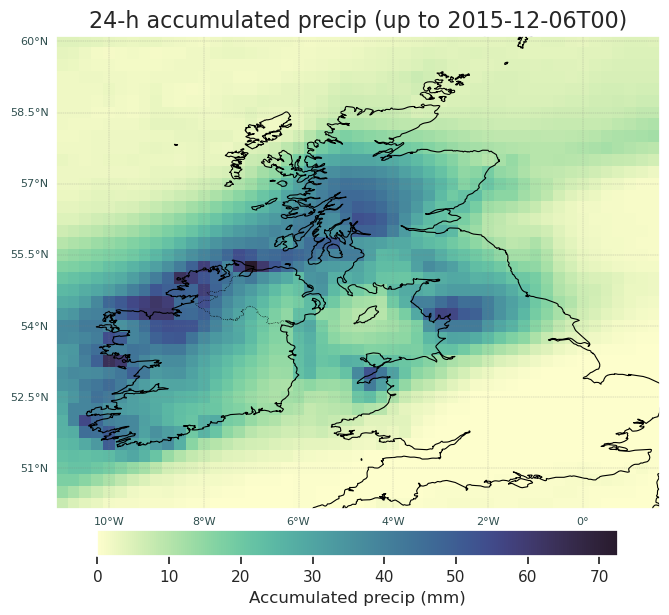

In [ ]:
rolling_window = 24
min_periods = rolling_window
cmap = cmocean.cm.deep

if rolling_window == 48:
    event_end_date = '2015-12-06T12'
elif rolling_window == 24:
    event_end_date = '2015-12-06T00'

ireland_bbox = [-10.5, -5.5, 51.5, 55.5]
dublin_bbox = []
uk_bbox = [-11.0, 1.5, 50.25, 60.0]
#uk_bbox = [-12.0, 2.5, 48.0, 60.0]

ds = xr.open_dataset('/mnt/metdata/2025s1985/era5/hourly_surface/tp/reanalysis-era5-single-levels_2015_month12.nc')
da_pr_roll = thr.preprocess_era5_rainfall(ds, 
                                          rolling_window=rolling_window, 
                                          min_periods=min_periods,
                                          event_end_date=event_end_date,
                                          bbox=uk_bbox, 
                                          lead_dim='valid_time')


fig = pf.formatted_uk_and_ireland_plot(da_pr_roll,
                                       bbox=uk_bbox,
                                       cmap=cmap)
out_file = f'/mnt/metdata/2025s1985/output_plots/desmond_dec2015/era5_eva/ERA5_Desmond_{rolling_window}h_{event_end_date}_prcp.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Read in the accumulated rainfall return levels

- Map the event to the relevant return period 
    - Input the event `xr.da` (i.e. accumulated rainfall corresponding to historical event)
    - Also input the `xr.da` containing return level values for the specified return periods (RPs), calculated separately by Kay 
    - Cycle through the RPs and return the first RP for which the return level threshold >= event rainfall 
    - Look at the structure of `da_pr_roll` (ERA5 accumulated precip) and replicate for the adjusted SFNO data accounting for differences in the input file structure 

In [3]:
# define relevant parameters for mapping to return periods
rp_dim = 'rl'
acc_dim = None
fill_value = np.nan
plot = False

# SFNO ensemble data 
event_str = 'sfno_adjusted_fcsts'
sfno_path = f'/mnt/metdata/2025s1985/{event_str}/Desmond_seed76_v2_sfno_adjusted_{rolling_window}h_windows.nc'
sfno_adjusted = xr.open_dataset(sfno_path)
# lead_rel=4 corresponds to the 'peak' time in the middle of the array (for each ensemble forecast)
sfno_adjusted = sfno_adjusted.sel(lead_rel=4)

# read in the return level data 
return_levels = xr.open_dataset(f'/mnt/metdata/2025s1985/era5_eva/{rolling_window}h/UKI_return_levels_{rolling_window}h_WY1980-2021.nc')
return_levels['return_level'] = return_levels['return_level'] * 1000.0  # convert from m to mm
return_levels = pf.select_subset_by_bbox(return_levels, bbox=uk_bbox)[0]
thresholds_da = return_levels['return_level']

# create a list to hold the RP arrays 
mapped_rp_list = []

# Loop over ensemble members and calculate RPs for each forecast
for val in sfno_adjusted['block'].values:
    event_da = sfno_adjusted.sel(block=val)['precip_adjusted']

    # map the event data to return periods
    mapped_rp_da = thr.map_event_to_return_period(event_da=event_da,
                                                  thresholds_da=thresholds_da,
                                                  rp_dim=rp_dim,
                                                  acc_dim=acc_dim,
                                                  acc_value=rolling_window,
                                                  fill_value=fill_value,
                                                  bbox=ireland_bbox)
    
    # append RP data to the list 
    mapped_rp_list.append(mapped_rp_da)

    # plot the mapped return periods
    if plot:
        fig = pf.formatted_uk_and_ireland_plot(mapped_rp_da,
                                            bbox=uk_bbox,
                                            cmap='hot_r')
        out_file = f'/mnt/metdata/2025s1985/output_plots/desmond_dec2015/{event_str}/Desmond_{rolling_window}h_{event_end_date}_ens{val}_RPs.png'
        plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)
        plt.close()

## Call the same function again

- Instead plot the adjusted, accumulated precip for each ensemble forecast

In [4]:
# define relevant parameters for mapping to return periods
rp_dim = 'rl'
acc_dim = None
fill_value = np.nan

# SFNO ensemble data 
event_str = 'sfno_adjusted_fcsts'
sfno_path = f'/mnt/metdata/2025s1985/{event_str}/Desmond_seed76_v2_sfno_adjusted_{rolling_window}h_windows.nc'
sfno_adjusted = xr.open_dataset(sfno_path)
# lead_rel=4 corresponds to the 'peak' time in the middle of the array (for each ensemble forecast)
sfno_adjusted = sfno_adjusted.sel(lead_rel=4)
var_name = f'{rolling_window}h accumulated precipitation'
sfno_adjusted = sfno_adjusted.rename({'precip_adjusted':var_name})

# read in the return level data 
return_levels = xr.open_dataset(f'/mnt/metdata/2025s1985/era5_eva/{rolling_window}h/UKI_return_levels_{rolling_window}h_WY1980-2021.nc')
return_levels['return_level'] = return_levels['return_level'] * 1000.0  # convert from m to mm
return_levels = pf.select_subset_by_bbox(return_levels, bbox=uk_bbox)[0]
thresholds_da = return_levels['return_level']

# Loop over ensemble members and calculate RPs for each forecast
for val in sfno_adjusted['block'].values:
    event_da = sfno_adjusted.sel(block=val)[var_name]

    # plot the mapped return periods
    fig = pf.formatted_uk_and_ireland_plot(event_da,
                                           bbox=uk_bbox,
                                           cmap=cmap)
    out_file = f'/mnt/metdata/2025s1985/output_plots/desmond_dec2015/{event_str}/Desmond_{rolling_window}h_{event_end_date}_ens{val}_prcp.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close()

## Convert the `xr.da` objects into `pd.df` before writing to csv

- One csv per ensemble member

In [5]:
out_dir = f'/mnt/metdata/2025s1985/sfno_adjusted_fcsts/output_RPs/{rolling_window}h'

# assume list_of_da contains one DataArray per ensemble forecast
for i, da_member in enumerate(mapped_rp_list):
    df = thr.da_grid_to_point_df(da_member, value_name='return_period', dropna=True)
    df['member'] = i
    out_fname = f"{out_dir}/Desmond_ens{i:02d}_{rolling_window}_{event_end_date}_return_periods.csv"
    df.to_csv(out_fname, index=False)